# Brent Oil Price Analysis

## Exploratory Data Analysis (EDA)

### Project Objective

This project analyzes historical Brent crude oil prices to understand:

- Long-term price trends
- Market volatility patterns
- Statistical properties of the time series
- Structural changes that may represent important market events

The analysis prepares the dataset for later Bayesian Change Point Detection modeling.

---

### Dataset Description

The dataset contains daily Brent crude oil prices.

Features:

| Column | Description |
|---|---|
| Date | Date of observation |
| Price | Brent crude oil price in USD per barrel |

---

### Analysis Workflow

1. Data loading and preprocessing
2. Data quality assessment
3. Exploratory visualization
4. Statistical analysis
5. Stationarity testing
6. Preparation for Bayesian modeling

In [1]:
import sys

!{sys.executable} -m pip install statsmodels

In [2]:
import statsmodels

print(statsmodels.__version__)

0.14.6


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import sys
import os


# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))


from src.data_loader import load_brent_data
from src.preprocessing import inspect_data, check_duplicates
from src.statistics import adf_test


plt.style.use("seaborn-v0_8")

In [4]:
data_path = "../data/BrentOilPrices.csv"

df = load_brent_data(data_path)

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


In [6]:
df.shape

(9011, 2)

In [7]:
inspect_data(df)


Shape
(9011, 2)

Columns
Index(['Date', 'Price'], dtype='str')

Missing Values
Date     0
Price    0
dtype: int64

Summary Statistics
                             Date        Price
count                        9011  9011.000000
mean   2005-02-10 23:46:53.760958    48.420782
min           1987-05-20 00:00:00     9.100000
25%           1996-03-20 12:00:00    19.050000
50%           2005-02-02 00:00:00    38.570000
75%           2014-01-09 12:00:00    70.090000
max           2022-11-14 00:00:00   143.950000
std                           NaN    32.860110


In [8]:
duplicates = check_duplicates(df)

duplicates

,Date,Price


## 7. Brent Oil Price Trend Analysis

The first step in understanding the Brent oil price dataset is visualizing the historical price movement.

This visualization helps identify:

- Long-term trends
- Major increases and decreases
- Possible structural changes
- Periods of high market uncertainty

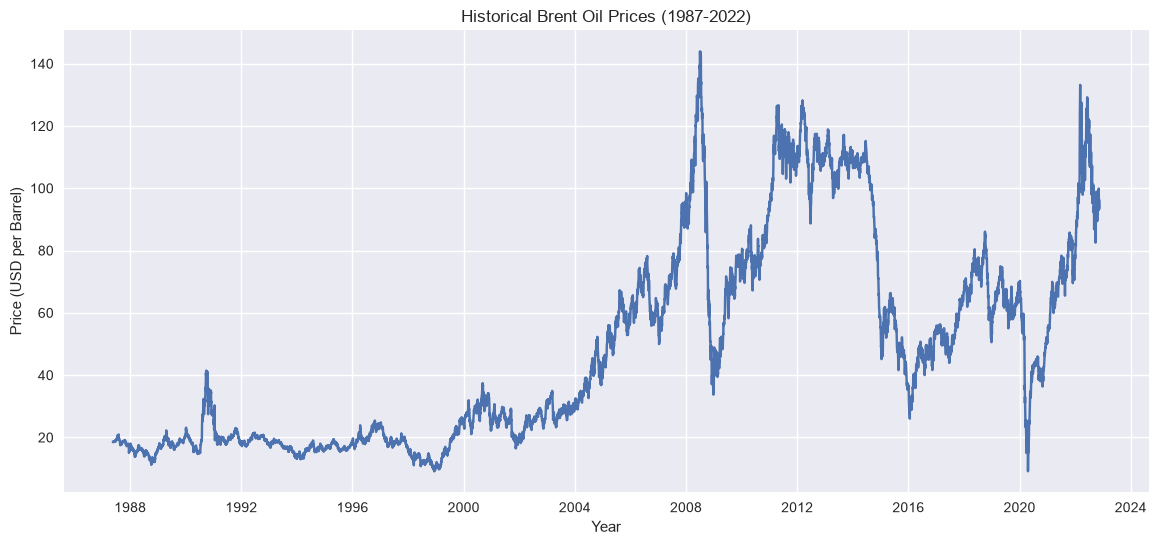

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Price"]
)

plt.title("Historical Brent Oil Prices (1987-2022)")

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.grid(True)

plt.show()

## 8. Price Distribution Analysis

Understanding the distribution of prices helps identify:

- Average price levels
- Extreme values
- Possible outliers
- Market behavior changes

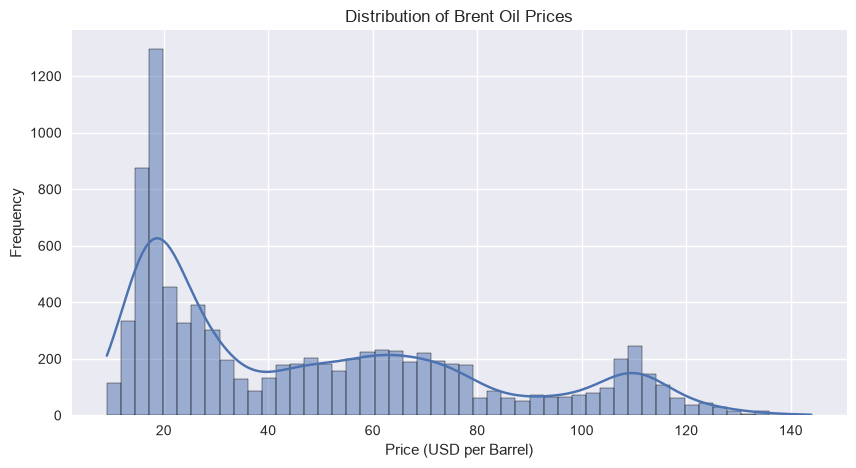

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Brent Oil Prices")

plt.xlabel("Price (USD per Barrel)")

plt.ylabel("Frequency")

plt.show()

## 9. Rolling Mean Analysis

A rolling mean smooths short-term fluctuations and helps identify the underlying trend.

A 365-day rolling mean is used because the dataset contains daily observations and one year provides a meaningful long-term window.

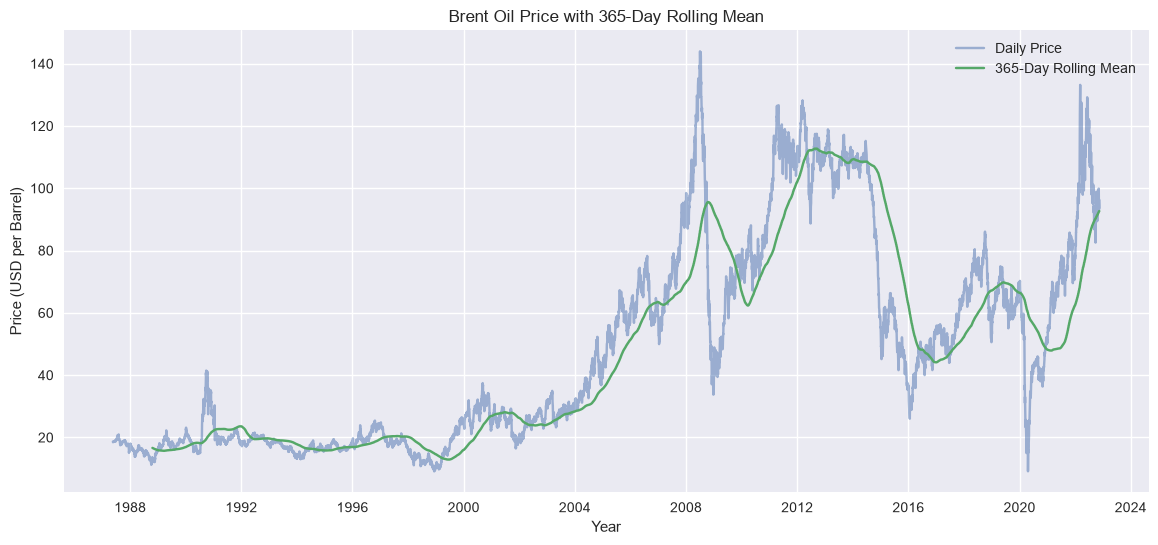

In [11]:
df["Rolling_Mean_365"] = (
    df["Price"]
    .rolling(window=365)
    .mean()
)


plt.figure(figsize=(14,6))


plt.plot(
    df["Date"],
    df["Price"],
    label="Daily Price",
    alpha=0.5
)


plt.plot(
    df["Date"],
    df["Rolling_Mean_365"],
    label="365-Day Rolling Mean"
)


plt.title(
    "Brent Oil Price with 365-Day Rolling Mean"
)


plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.legend()

plt.grid(True)

plt.show()

## 10. Volatility Analysis

Oil markets experience periods of instability due to:

- Geopolitical events
- Economic crises
- Supply disruptions
- Demand changes

Rolling standard deviation is used to measure price variability over time.

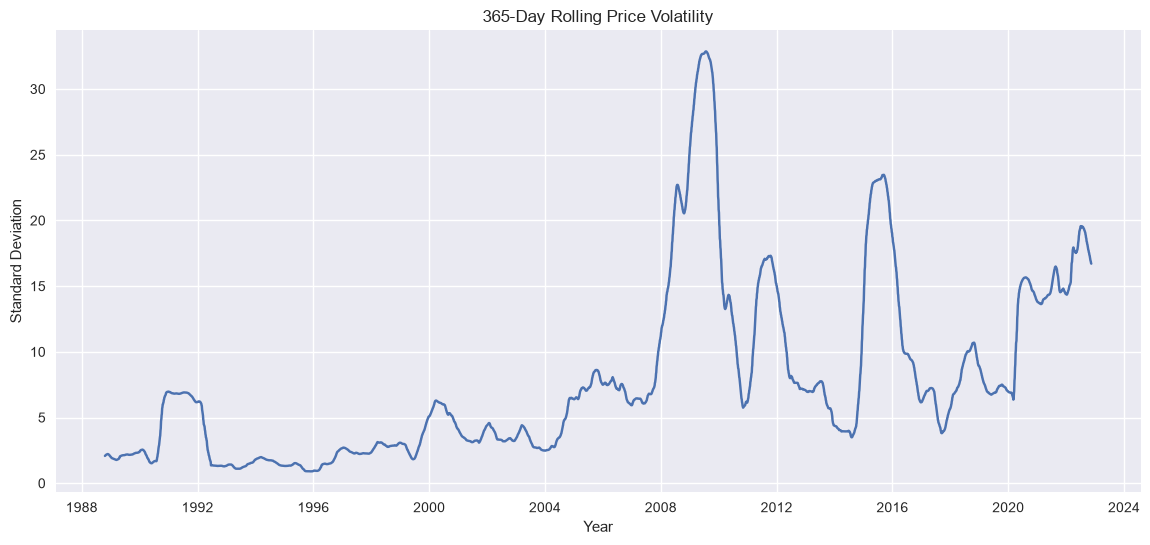

In [12]:
df["Rolling_Std_365"] = (
    df["Price"]
    .rolling(window=365)
    .std()
)


plt.figure(figsize=(14,6))


plt.plot(
    df["Date"],
    df["Rolling_Std_365"]
)


plt.title(
    "365-Day Rolling Price Volatility"
)


plt.xlabel("Year")

plt.ylabel("Standard Deviation")


plt.grid(True)

plt.show()

## 11. Stationarity Test (Augmented Dickey-Fuller)

The Augmented Dickey-Fuller (ADF) test determines whether a time series is stationary.

A stationary series has:

- Constant mean
- Constant variance
- No time-dependent structure

This is important because many time-series models require stationary data.

In [13]:
price_series = df["Price"]

adf_test(price_series)

ADF Statistic : -1.9938560113924675
p-value : 0.28927350489340287
Critical Values
1% -3.4310783342658615
5% -2.861861876398633
10% -2.566941329781918


## ADF Test Results Interpretation

The Augmented Dickey-Fuller (ADF) test was applied to the Brent oil price series to evaluate stationarity.

### Results

- ADF Statistic: -1.994
- p-value: 0.289

The p-value is greater than the common significance level of 0.05.

Therefore, we fail to reject the null hypothesis that the time series contains a unit root.

### Conclusion

The Brent oil price series is **non-stationary**.

This behavior is expected for financial price data because oil prices usually contain:

- Long-term trends
- Market cycles
- Structural changes caused by economic and geopolitical events

For future modeling, especially Bayesian Change Point Detection, it is important to consider transformations such as:

- Log returns
- Price differences
- Percentage changes

because these transformed series are often more suitable for detecting changes in market behavior.

In [14]:
df["Rolling_Mean_365"]
df["Rolling_Std_365"]

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
9006    16.857916
9007    16.819423
9008    16.782916
9009    16.745589
9010    16.708599
Name: Rolling_Std_365, Length: 9011, dtype: float64

# 12. Brent Oil Returns Analysis

Since oil prices are non-stationary, we transform the price series into daily returns.

Returns measure the relative change in price between consecutive trading days.

This transformation helps:

- Remove long-term trends
- Analyze market movements
- Identify periods of unusual volatility
- Prepare data for Bayesian change point detection

In [15]:
df["Return"] = df["Price"].pct_change()

df.head()

,Date,Price,Rolling_Mean_365,Rolling_Std_365,Return
0,1987-05-20,18.63,NaN,NaN,NaN
1,1987-05-21,18.45,NaN,NaN,-0.009662
2,1987-05-22,18.55,NaN,NaN,0.005420
3,1987-05-25,18.60,NaN,NaN,0.002695
4,1987-05-26,18.63,NaN,NaN,0.001613


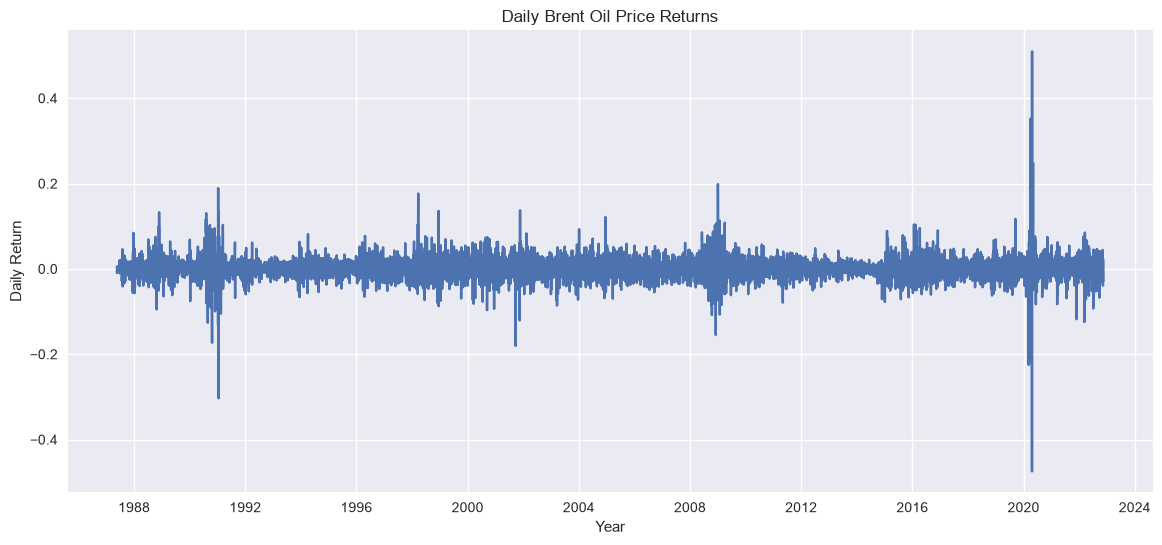

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Return"]
)

plt.title("Daily Brent Oil Price Returns")

plt.xlabel("Year")

plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

In [17]:
df["Return"].describe()

count    9010.000000
mean        0.000501
std         0.025255
min        -0.474654
25%        -0.011092
50%         0.000402
75%         0.012201
max         0.509868
Name: Return, dtype: float64

## Daily Return Statistics Interpretation

The daily return distribution shows the characteristics of Brent oil market movements.

Key observations:

- The average daily return is close to zero, which is common for financial assets.
- The standard deviation indicates significant daily volatility.
- Extreme minimum and maximum returns show the presence of large market shocks.

These extreme movements may correspond to major geopolitical, economic, or supply-demand events.

The return series is more suitable than raw prices for identifying structural changes because it removes the long-term price trend.

In [18]:
adf_test(df["Return"].dropna())

ADF Statistic : -17.11168481990272
p-value : 7.358230367030982e-30
Critical Values
1% -3.431078253154464
5% -2.8618618405570615
10% -2.5669413107032493


## ADF Test Interpretation for Returns

The Augmented Dickey-Fuller test was applied to the daily return series.

Results:

- ADF Statistic: -17.112
- p-value: approximately 0

The p-value is significantly smaller than 0.05.

Therefore, we reject the null hypothesis and conclude that the return series is stationary.

### Conclusion

Unlike the original price series, Brent oil returns are stationary.

This confirms that returns are more appropriate for statistical modeling and Bayesian Change Point Detection.

The stationary return series will be used in later modeling stages to identify changes in market regimes.

In [19]:
events = pd.read_csv("../data/events.csv")

events.head()

,Event,Start_Date,Category,Description
0,Gulf War,1990-08-02,Conflict,Iraq invaded Kuwait causing major oil supply c...
1,Asian Financial Crisis,1997-07-02,Economic,Reduced oil demand across Asia leading to pric...
2,September 11 Attacks,2001-09-11,Geopolitical,Terrorist attacks created uncertainty in globa...
3,Iraq War,2003-03-20,Conflict,Military invasion of Iraq affected global oil ...
4,Global Financial Crisis,2008-09-15,Economic,Financial market collapse sharply reduced oil ...


# 13. Historical Event Analysis

Oil prices are strongly influenced by geopolitical and economic events.

This section compares major historical events with Brent oil price movements.

The purpose is to:

- Understand possible causes of price changes
- Validate unusual movements
- Prepare for Bayesian change point analysis

In [20]:
events = pd.read_csv("../data/events.csv")

events["Start_Date"] = pd.to_datetime(events["Start_Date"])

events.head()

,Event,Start_Date,Category,Description
0,Gulf War,1990-08-02,Conflict,Iraq invaded Kuwait causing major oil supply c...
1,Asian Financial Crisis,1997-07-02,Economic,Reduced oil demand across Asia leading to pric...
2,September 11 Attacks,2001-09-11,Geopolitical,Terrorist attacks created uncertainty in globa...
3,Iraq War,2003-03-20,Conflict,Military invasion of Iraq affected global oil ...
4,Global Financial Crisis,2008-09-15,Economic,Financial market collapse sharply reduced oil ...


In [21]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Event        15 non-null     str           
 1   Start_Date   15 non-null     datetime64[us]
 2   Category     15 non-null     str           
 3   Description  15 non-null     str           
dtypes: datetime64[us](1), str(3)
memory usage: 612.0 bytes


In [22]:
events["Category"].value_counts()

Category
Conflict        5
OPEC            3
Economic        2
Sanctions       2
Geopolitical    1
Political       1
Health          1
Name: count, dtype: int64

## Brent Oil Prices with Historical Events

The following visualization shows major historical events on the Brent oil price timeline.

Vertical markers represent known events that may have influenced market behavior.

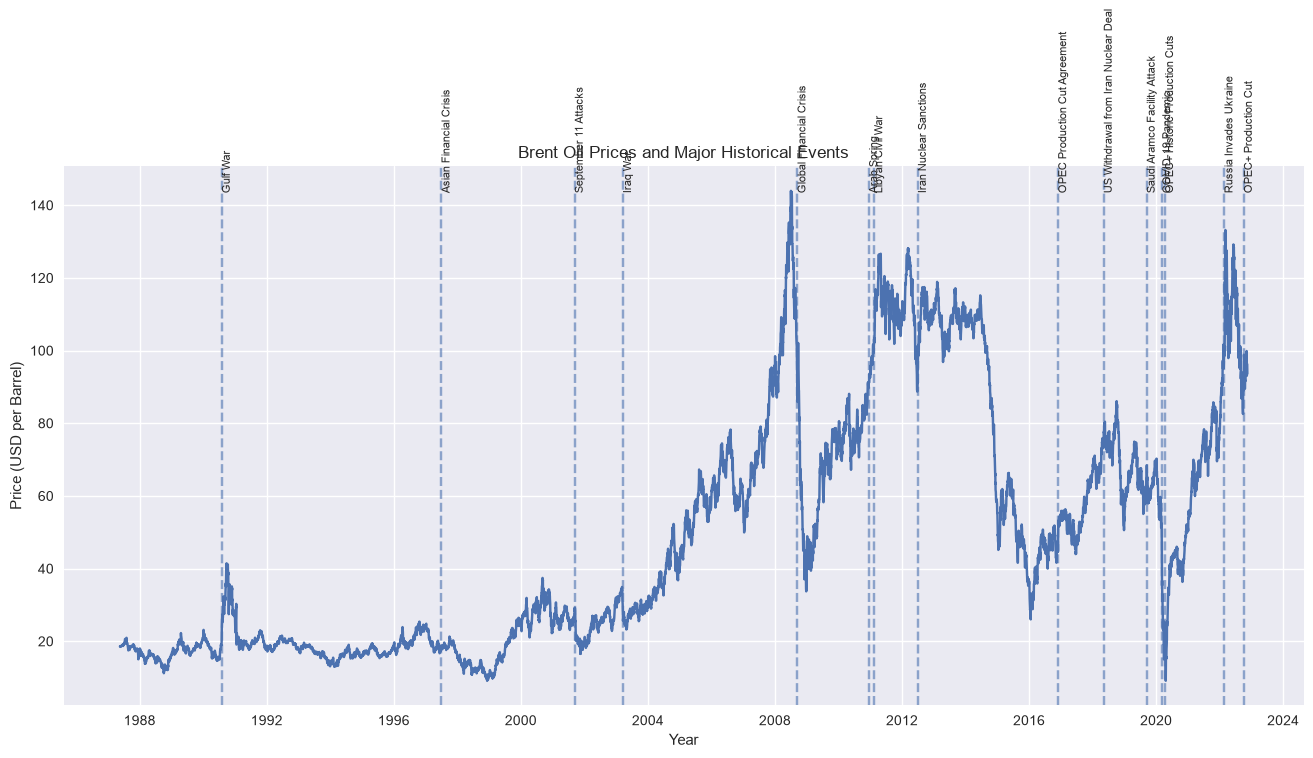

In [23]:
plt.figure(figsize=(16,7))


plt.plot(
    df["Date"],
    df["Price"],
    label="Brent Oil Price"
)


for _, event in events.iterrows():

    plt.axvline(
        event["Start_Date"],
        linestyle="--",
        alpha=0.6
    )

    plt.text(
        event["Start_Date"],
        df["Price"].max(),
        event["Event"],
        rotation=90,
        fontsize=8
    )


plt.title(
    "Brent Oil Prices and Major Historical Events"
)

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.grid(True)

plt.show()

In [24]:
event_analysis = []

for _, event in events.iterrows():

    event_date = event["Start_Date"]

    before = df[
        (df["Date"] >= event_date - pd.Timedelta(days=30)) &
        (df["Date"] < event_date)
    ]["Price"]

    after = df[
        (df["Date"] >= event_date) &
        (df["Date"] <= event_date + pd.Timedelta(days=30))
    ]["Price"]


    if len(before) > 0 and len(after) > 0:

        change = (
            after.mean() - before.mean()
        )

        event_analysis.append(
            {
                "Event": event["Event"],
                "Category": event["Category"],
                "Price_Change_30_Days": change
            }
        )


event_impact = pd.DataFrame(event_analysis)

event_impact

,Event,Category,Price_Change_30_Days
0,Gulf War,Conflict,10.121364
1,Asian Financial Crisis,Economic,0.925714
2,September 11 Attacks,Geopolitical,-2.575300
3,Iraq War,Conflict,-6.989545
4,Global Financial Crisis,Economic,-18.049153
5,Arab Spring,Political,6.787619
6,Libyan Civil War,Conflict,12.380045
7,Iran Nuclear Sanctions,Sanctions,7.462857
8,OPEC Production Cut Agreement,OPEC,8.398788
9,US Withdrawal from Iran Nuclear Deal,Sanctions,3.290455


In [25]:
events.shape

(15, 4)

In [26]:
events["Category"].value_counts()

Category
Conflict        5
OPEC            3
Economic        2
Sanctions       2
Geopolitical    1
Political       1
Health          1
Name: count, dtype: int64

In [27]:
event_impact

,Event,Category,Price_Change_30_Days
0,Gulf War,Conflict,10.121364
1,Asian Financial Crisis,Economic,0.925714
2,September 11 Attacks,Geopolitical,-2.575300
3,Iraq War,Conflict,-6.989545
4,Global Financial Crisis,Economic,-18.049153
5,Arab Spring,Political,6.787619
6,Libyan Civil War,Conflict,12.380045
7,Iran Nuclear Sanctions,Sanctions,7.462857
8,OPEC Production Cut Agreement,OPEC,8.398788
9,US Withdrawal from Iran Nuclear Deal,Sanctions,3.290455


## Event Impact Analysis

To understand the effect of historical events on Brent oil prices, we calculate the average price difference between:

- 30 days before the event
- 30 days after the event

Positive values indicate price increases after an event.

Negative values indicate price decreases after an event.

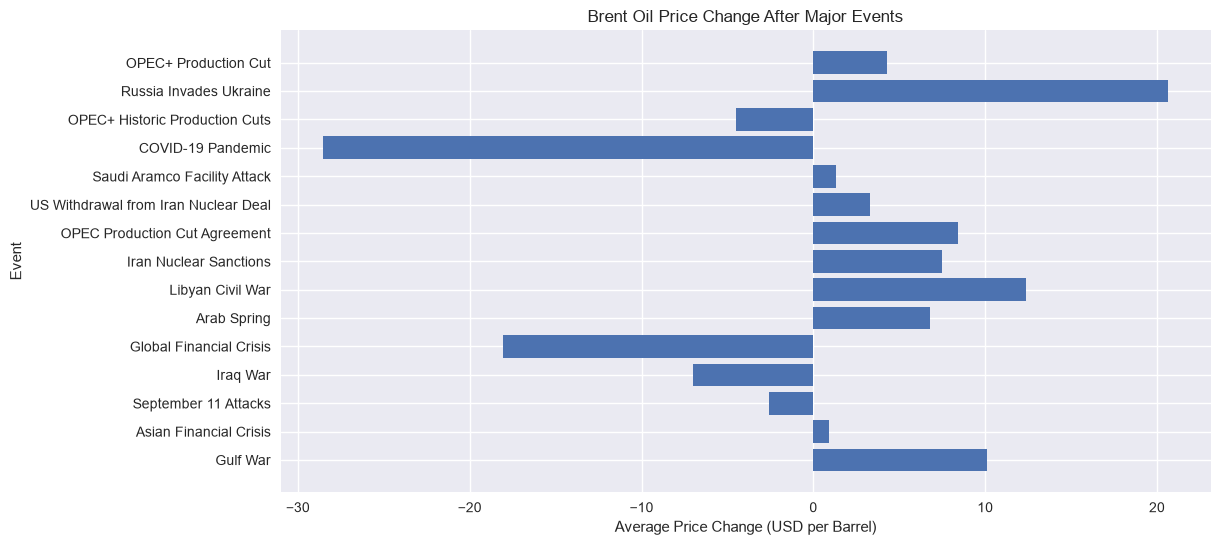

In [28]:
plt.figure(figsize=(12,6))


plt.barh(
    event_impact["Event"],
    event_impact["Price_Change_30_Days"]
)


plt.title(
    "Brent Oil Price Change After Major Events"
)


plt.xlabel(
    "Average Price Change (USD per Barrel)"
)


plt.ylabel(
    "Event"
)


plt.grid(True)

plt.show()

## Event Analysis Findings

The event analysis shows that major historical events are associated with noticeable changes in Brent oil prices.

Key observations:

- Conflict events can create supply uncertainty and price increases.
- Economic crises can reduce demand and pressure prices downward.
- OPEC decisions can influence global supply expectations.
- Health and financial events can create periods of unusual volatility.

These observations support the use of Bayesian Change Point Detection to identify periods where market behavior changed significantly.

In [29]:
import pymc as pm
import pytensor
import arviz as az

print(pm.__version__)
print(pytensor.__version__)
print(az.__version__)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


5.28.5
2.38.3
0.23.4


# =====================================================
# Bayesian Change Point Model
# =====================================================

In [30]:
print(df.columns)

Index(['Date', 'Price', 'Rolling_Mean_365', 'Rolling_Std_365', 'Return'], dtype='str')


In [31]:
import numpy as np

df["Log_Return"] = np.log(df["Price"]).diff()

df.head()

,Date,Price,Rolling_Mean_365,Rolling_Std_365,Return,Log_Return
0,1987-05-20,18.63,NaN,NaN,NaN,NaN
1,1987-05-21,18.45,NaN,NaN,-0.009662,-0.009709
2,1987-05-22,18.55,NaN,NaN,0.005420,0.005405
3,1987-05-25,18.60,NaN,NaN,0.002695,0.002692
4,1987-05-26,18.63,NaN,NaN,0.001613,0.001612


In [32]:
df.columns

Index(['Date', 'Price', 'Rolling_Mean_365', 'Rolling_Std_365', 'Return',
       'Log_Return'],
      dtype='str')

In [33]:
df["Log_Return"].isna().sum()

np.int64(1)

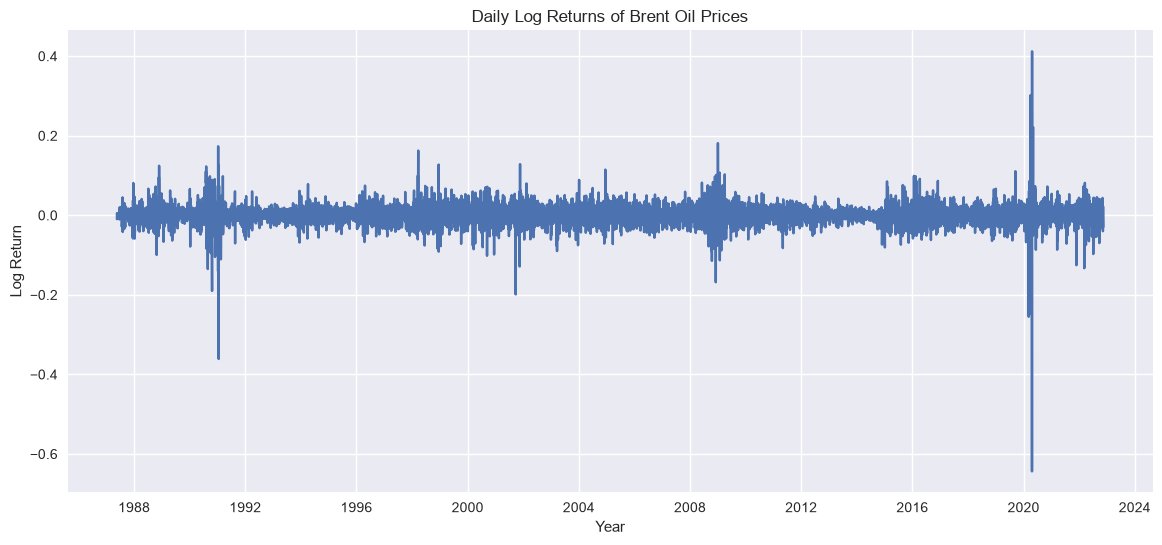

In [34]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Log_Return"]
)

plt.title("Daily Log Returns of Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

In [35]:
adf_test(df["Log_Return"].dropna())

ADF Statistic : -16.427113494485894
p-value : 2.4985801611428892e-29
Critical Values
1% -3.4310783342658615
5% -2.861861876398633
10% -2.566941329781918


In [36]:
model_data = df["Log_Return"].dropna().to_numpy()

print(model_data.shape)

(9010,)


In [37]:
model_data = model_data[-2000:]

print(model_data.shape)

(2000,)


In [38]:
model_data = df["Log_Return"].dropna().to_numpy()

In [39]:
print(model_data.shape)

(9010,)


In [40]:
# Use the last 2000 observations for the initial model
model_data = df["Log_Return"].dropna().to_numpy()[-2000:]

n = len(model_data)

print("Number of observations:", n)

Number of observations: 2000


In [41]:
time_index = np.arange(n)

time_index

array([   0,    1,    2, ..., 1997, 1998, 1999], shape=(2000,))

In [42]:
with pm.Model() as change_point_model:

    # Change point prior
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n - 1
    )

    # Mean before change
    mu_1 = pm.Normal(
        "mu_1",
        mu=0,
        sigma=1
    )

    # Mean after change
    mu_2 = pm.Normal(
        "mu_2",
        mu=0,
        sigma=1
    )

    # Standard deviation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    # Switch between the two means
    mu = pm.math.switch(
        time_index < tau,
        mu_1,
        mu_2
    )

    # Likelihood
    likelihood = pm.Normal(
        "likelihood",
        mu=mu,
        sigma=sigma,
        observed=model_data
    )

print("Model successfully created.")

Model successfully created.


In [46]:
returns = (
    df["Log_Return"]
    .dropna()
    .values[:2000]
)


with change_point_model:

    trace = pm.sample(
        draws=300,
        tune=300,
        chains=2,
        cores=1,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True
    )

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 6379 seconds.
There were 33 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [47]:
import arviz as az

summary = az.summary(trace)

summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,1043.297,665.939,32.000,1993.000,431.621,103.387,3.0,16.0,2.09
mu_1,-0.000,0.004,-0.006,0.004,0.000,0.001,178.0,29.0,1.16
mu_2,0.001,0.003,-0.006,0.005,0.000,0.001,70.0,53.0,1.22
sigma,0.034,0.001,0.033,0.035,0.000,0.000,122.0,175.0,1.04


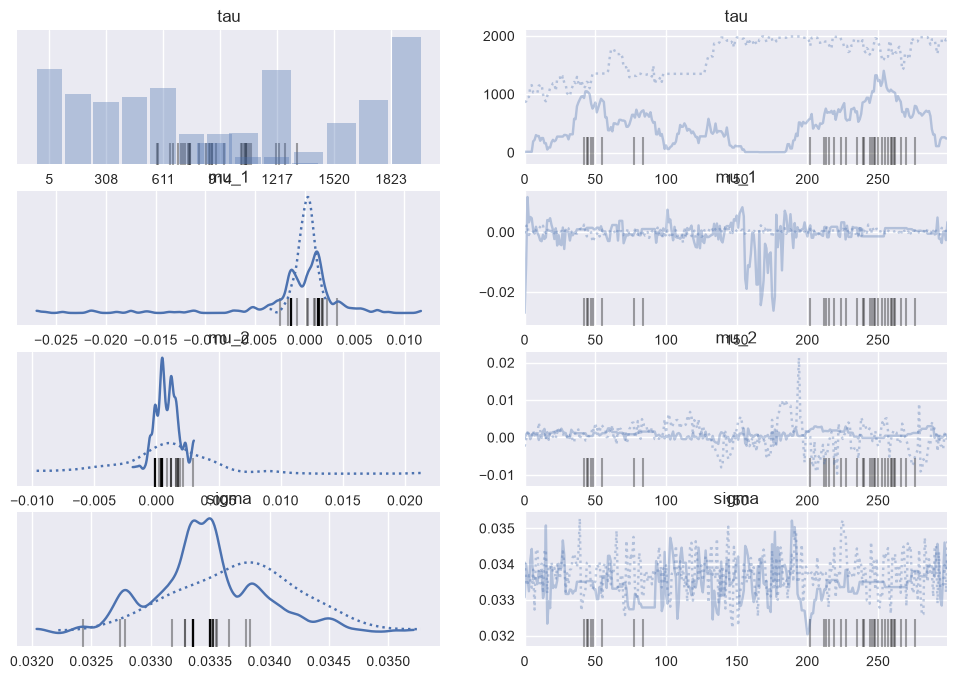

In [48]:
az.plot_trace(
    trace,
    var_names=["tau", "mu_1", "mu_2", "sigma"]
);

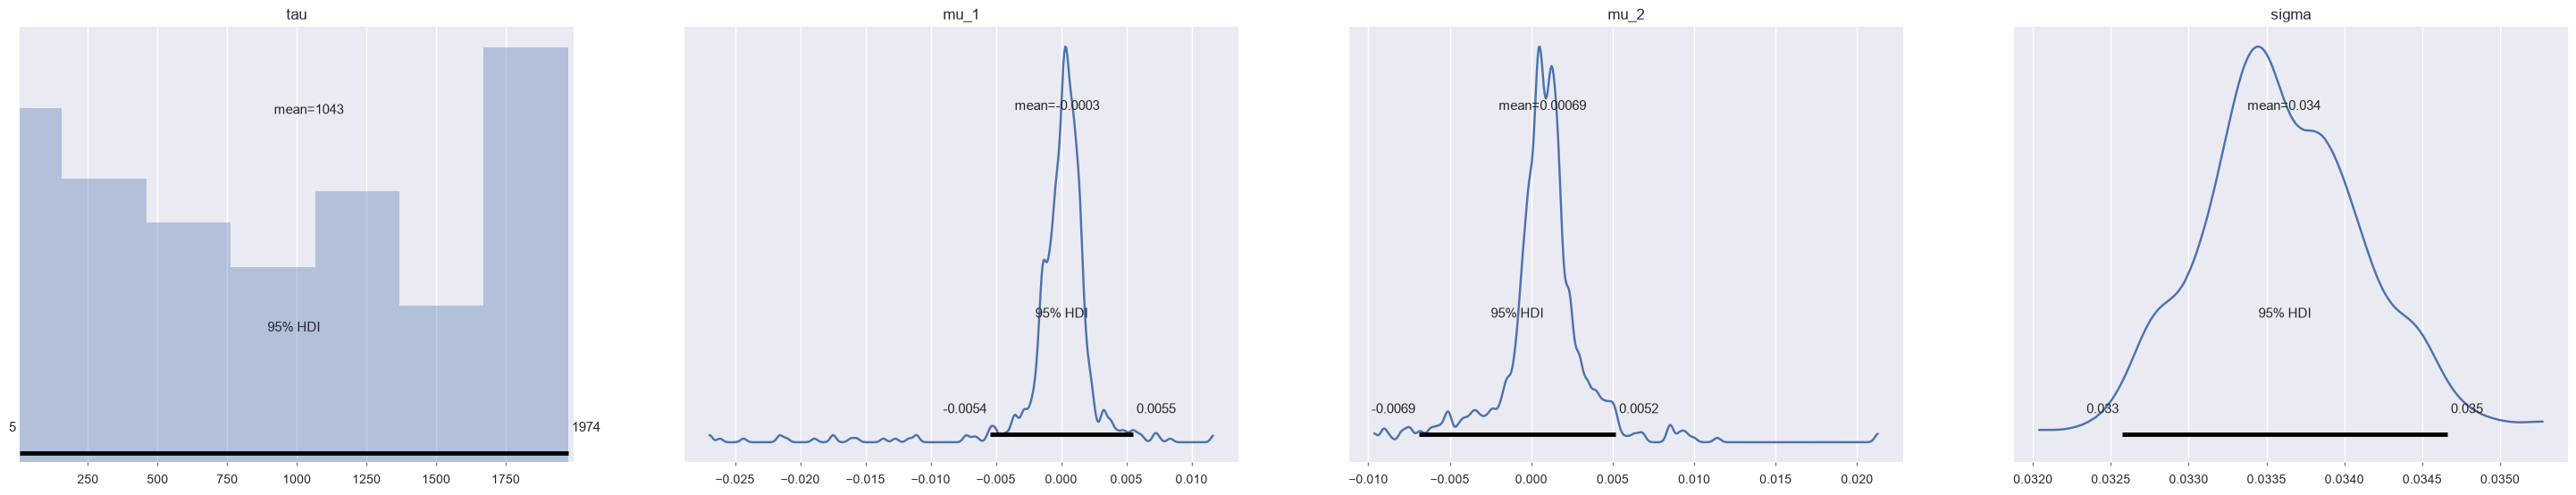

In [49]:
az.plot_posterior(
    trace,
    var_names=["tau", "mu_1", "mu_2", "sigma"],
    hdi_prob=0.95
);

In [50]:
tau_samples = trace.posterior["tau"].values.flatten()

tau_estimate = int(np.round(tau_samples.mean()))

print("Estimated tau:", tau_estimate)

Estimated tau: 1043


In [51]:
model_dates = (
    df["Date"]
      .iloc[1:]
      .iloc[-2000:]
      .reset_index(drop=True)
)

change_point_date = model_dates.iloc[tau_estimate]

print("Estimated Change Point Date:", change_point_date)

Estimated Change Point Date: 2019-02-13 00:00:00


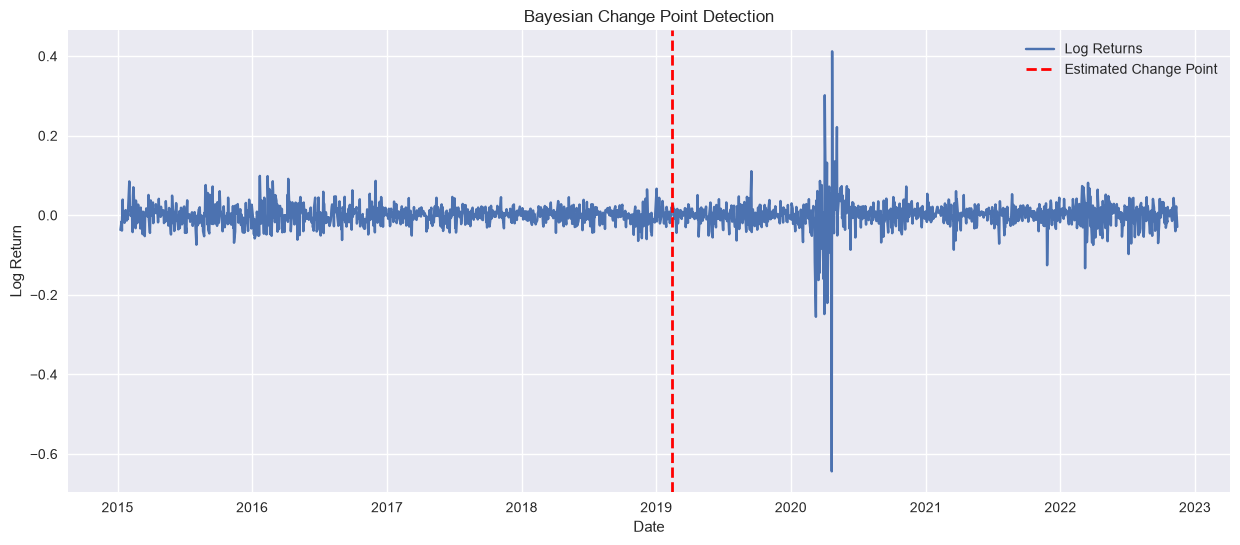

In [52]:
plt.figure(figsize=(15,6))

plt.plot(
    model_dates,
    model_data,
    label="Log Returns"
)

plt.axvline(
    change_point_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Estimated Change Point"
)

plt.title("Bayesian Change Point Detection")

plt.xlabel("Date")

plt.ylabel("Log Return")

plt.legend()

plt.grid(True)

plt.show()

In [53]:
events["Days_Difference"] = (
    events["Start_Date"] - change_point_date
).abs().dt.days

closest_event = events.sort_values(
    "Days_Difference"
).iloc[0]

closest_event

Event                                   Saudi Aramco Facility Attack
Start_Date                                       2019-09-14 00:00:00
Category                                                    Conflict
Description        Attack temporarily disrupted Saudi oil product...
Days_Difference                                                  213
Name: 10, dtype: object

In [54]:
before = model_data[:tau_estimate]
after = model_data[tau_estimate:]

before_mean = before.mean()
after_mean = after.mean()

percent_change = (
    (after_mean - before_mean)
    / abs(before_mean)
) * 100 if before_mean != 0 else np.nan

print(f"Mean before: {before_mean:.6f}")
print(f"Mean after : {after_mean:.6f}")
print(f"Percentage change: {percent_change:.2f}%")

Mean before: 0.000226
Mean after : 0.000421
Percentage change: 85.96%


In [55]:
import numpy as np
from numpy.lib.array_utils import normalize_axis_index

print("NumPy works!")

NumPy works!
